In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
from pathlib import Path

# Project Root
BASE_DIR = Path.cwd().parent

# Folders
RAW_DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"

REPORT_DIR = BASE_DIR / "reports" / "charts"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root :", BASE_DIR)
print("Raw Data     :", RAW_DATA_DIR)
print("Processed    :", PROCESSED_DATA_DIR)
print("Reports      :", REPORT_DIR)

Project Root : c:\Users\Dell\OneDrive\Documents\bluestock-data-analytics-internship
Raw Data     : c:\Users\Dell\OneDrive\Documents\bluestock-data-analytics-internship\data\raw
Processed    : c:\Users\Dell\OneDrive\Documents\bluestock-data-analytics-internship\data\processed
Reports      : c:\Users\Dell\OneDrive\Documents\bluestock-data-analytics-internship\reports\charts


In [4]:
# Cleaned datasets

nav = pd.read_csv(
    PROCESSED_DATA_DIR / "02_nav_history_cleaned.csv",
    parse_dates=["date"]
)

performance = pd.read_csv(
    PROCESSED_DATA_DIR / "07_scheme_performance_cleaned.csv"
)

transactions = pd.read_csv(
    PROCESSED_DATA_DIR / "08_investor_transactions_cleaned.csv",
    parse_dates=["transaction_date"]
)

# Raw datasets

aum = pd.read_csv(
    RAW_DATA_DIR / "03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    RAW_DATA_DIR / "04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    RAW_DATA_DIR / "05_category_inflows.csv"
)

folio = pd.read_csv(
    RAW_DATA_DIR / "06_industry_folio_count.csv"
)

portfolio = pd.read_csv(
    RAW_DATA_DIR / "09_portfolio_holdings.csv"
)

benchmark = pd.read_csv(
    RAW_DATA_DIR / "10_benchmark_indices.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [8]:
datasets = {
    "NAV": nav,
    "Performance": performance,
    "Transactions": transactions,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:15} {df.shape}")

NAV             (46000, 3)
Performance     (40, 19)
Transactions    (32778, 13)
AUM             (90, 5)
SIP             (48, 6)
Category        (144, 3)
Folio           (21, 6)
Portfolio       (322, 8)
Benchmark       (8050, 3)


In [5]:
# Merge NAV history with scheme information

nav_plot = nav.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_plot.shape)

nav_plot.head()

(46000, 4)


,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [6]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026) for All Mutual Fund Schemes",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    height=700,
    width=1200,
    template="plotly_white",
    legend_title="Scheme Name"
)

fig.show()

In [7]:
fig.write_html(REPORT_DIR / "nav_trend_all_schemes.html")

print("Chart saved successfully.")

Chart saved successfully.


## Insight 1

The daily NAV trend from 2022 to 2026 shows an overall upward movement across most mutual fund schemes. The highlighted 2023 period represents a broad market bull run, while the highlighted 2024 period indicates market correction phases with temporary declines before recovery.

In [8]:
print(aum.head())

print("\nColumns:")
print(aum.columns.tolist())

print("\nShape:")
print(aum.shape)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

Shape:
(90, 5)


In [9]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

print(aum.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


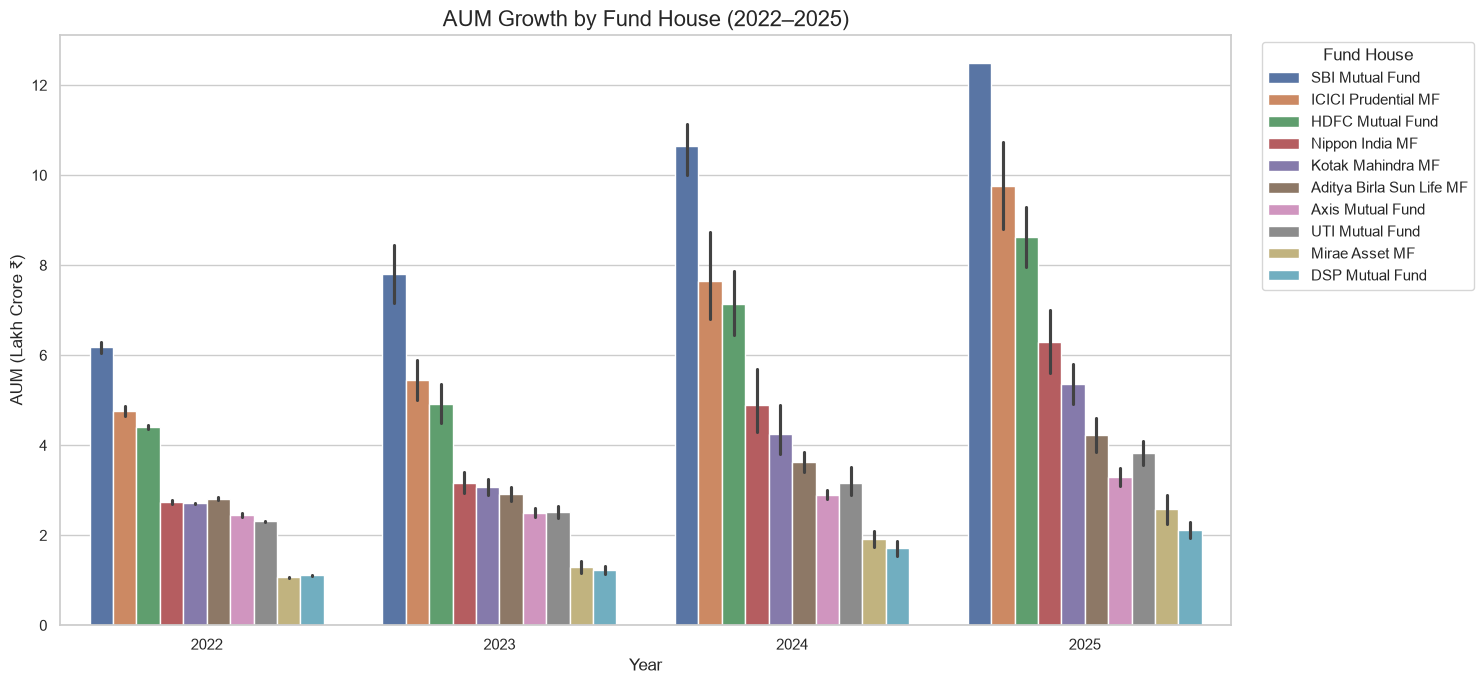

In [10]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)
plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [11]:
# Highest AUM record

top_aum = aum.loc[aum["aum_lakh_crore"].idxmax()]

print("Highest AUM Record")
print(top_aum)

Highest AUM Record
date              2025-03-31 00:00:00
fund_house            SBI Mutual Fund
aum_lakh_crore                   12.5
aum_crore                     1250000
num_schemes                       186
year                             2025
Name: 70, dtype: object


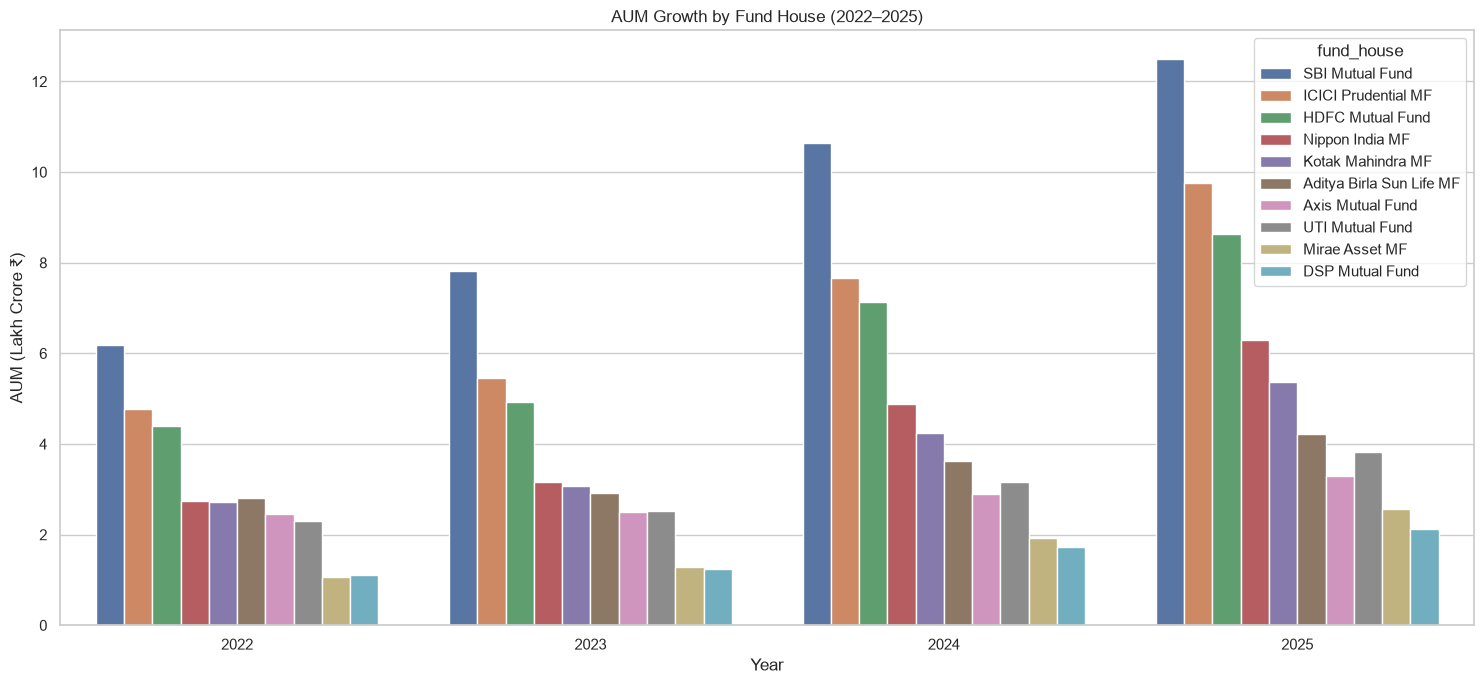

AUM chart saved successfully.


In [13]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
    errorbar=None
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("AUM chart saved successfully.")

## Insight 2

The Assets Under Management (AUM) increased steadily across major fund houses from 2022 to 2025. SBI Mutual Fund consistently maintained the highest AUM, demonstrating its dominant position in the Indian mutual fund industry.

In [14]:
print(sip.head())

print("\nColumns:")
print(sip.columns.tolist())

print("\nShape:")
print(sip.shape)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Shape:
(48, 6)


In [15]:
# Convert month to datetime

sip["month"] = pd.to_datetime(sip["month"])

print(sip.head())

       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   
3 2022-04-01             11863                       5.48   
4 2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [16]:
# Highest SIP inflow

max_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

print(max_sip)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [17]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Highlight highest SIP inflow
fig.add_annotation(
    x=max_sip["month"],
    y=max_sip["sip_inflow_crore"],
    text=f"All-Time High<br>₹{max_sip['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600
)

fig.show()

In [18]:
fig.write_html(REPORT_DIR / "sip_inflow_trend.html")

print("SIP trend chart saved successfully.")

SIP trend chart saved successfully.


## Insight 3

Monthly SIP inflows showed a consistent upward trend from 2022 to 2025, reflecting increasing retail investor participation. The highest monthly SIP inflow reached ₹31,002 crore in December 2025, indicating record investment activity.

In [19]:
print(category.head())

print("\nColumns:")
print(category.columns.tolist())

print("\nShape:")
print(category.shape)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0

Columns:
['month', 'category', 'net_inflow_crore']

Shape:
(144, 3)


In [20]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Convert to Month-Year format
category["month_name"] = category["month"].dt.strftime("%b-%Y")

print(category.head())

       month         category  net_inflow_crore month_name
0 2024-04-01        Large Cap            2413.0   Apr-2024
1 2024-04-01          Mid Cap            3897.0   Apr-2024
2 2024-04-01        Small Cap            3533.0   Apr-2024
3 2024-04-01        Flexi Cap            4947.0   Apr-2024
4 2024-04-01  Large & Mid Cap            4214.0   Apr-2024


In [24]:
# Keep months in chronological order
category = category.sort_values("month")

heatmap_data = category.pivot(
    index="category",
    columns="month_name",
    values="net_inflow_crore"
)

heatmap_data = heatmap_data[
    category["month_name"].drop_duplicates()
]

display(heatmap_data)

month_name,Apr-2024,May-2024,Jun-2024,Jul-2024,Aug-2024,Sep-2024,Oct-2024,Nov-2024,Dec-2024,Jan-2025,Feb-2025,Mar-2025
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


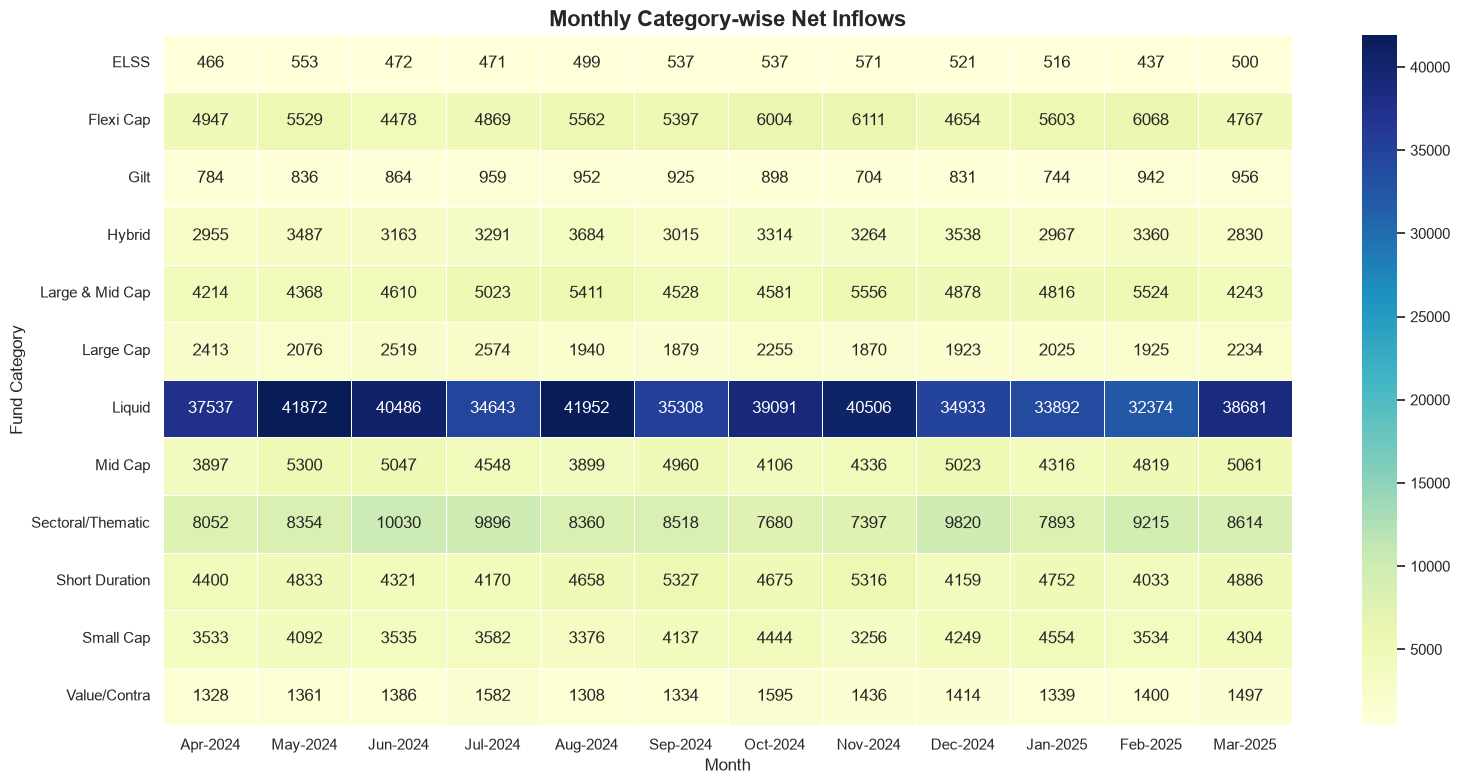

In [25]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Monthly Category-wise Net Inflows",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

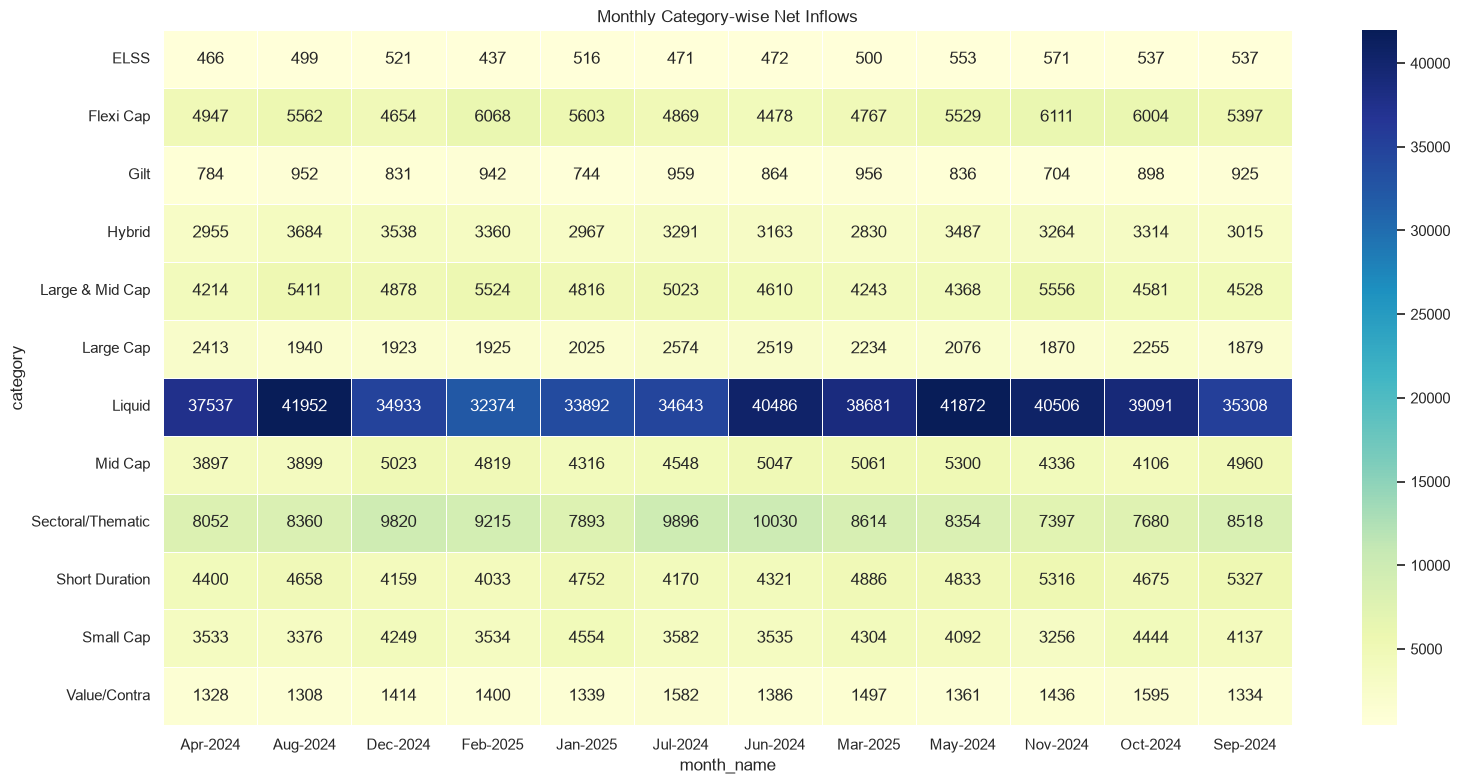

Category Heatmap saved successfully.


In [23]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Monthly Category-wise Net Inflows")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Category Heatmap saved successfully.")

## Insight 4

The category inflow heatmap shows that equity-oriented categories such as Flexi Cap, Mid Cap, and Small Cap consistently attracted higher net inflows than debt-oriented categories. Investor preference shifted toward equity funds during strong market periods.

In [26]:
print("Age Groups:")
print(transactions["age_group"].value_counts().sort_index())

print("\nGender:")
print(transactions["gender"].value_counts())

print("\nTransaction Types:")
print(transactions["transaction_type"].value_counts())

print("\nSIP Amount Statistics by Age Group:")
print(
    transactions.loc[
        transactions["transaction_type"].eq("SIP")
    ]
    .groupby("age_group")["amount_inr"]
    .describe()
    .round(2)
)

Age Groups:
age_group
18-25     4916
26-35    13463
36-45     8146
46-55     3779
56+       2474
Name: count, dtype: int64

Gender:
gender
Male      21809
Female    10969
Name: count, dtype: int64

Transaction Types:
transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

SIP Amount Statistics by Age Group:
            count      mean       std    min      25%     50%       75%  \
age_group                                                                 
18-25      2949.0  10953.07  14310.23  401.0  2072.00  5020.0  13059.00   
26-35      8063.0  10986.90  14169.07  400.0  2094.00  5070.0  13661.00   
36-45      4926.0  10885.76  13993.98  400.0  2157.25  5250.0  13221.25   
46-55      2300.0  11136.76  14268.80  400.0  2176.50  5136.0  13785.25   
56+        1478.0  11574.92  14950.66  406.0  2105.75  5420.5  14373.25   

               max  
age_group           
18-25      59904.0  
26-35      59998.0  
36-45      59928.0  
46-55      5

In [27]:
# -------------------------------
# Investor Demographics Preparation
# -------------------------------

# Define proper ordering
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]

transactions["age_group"] = pd.Categorical(
    transactions["age_group"],
    categories=age_order,
    ordered=True
)

# SIP transactions only (required for SIP amount analysis)
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

print("Investor records:", len(transactions))
print("SIP records:", len(sip_transactions))

Investor records: 32778
SIP records: 19716


In [28]:
age_counts = (
    transactions["age_group"]
    .value_counts()
    .reindex(age_order)
)

fig = px.pie(
    values=age_counts.values,
    names=age_counts.index,
    title="Investor Age Group Distribution",
    hole=0.40
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=600
)

fig.write_html(REPORT_DIR / "age_group_distribution.html")

fig.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_28640\2657349456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


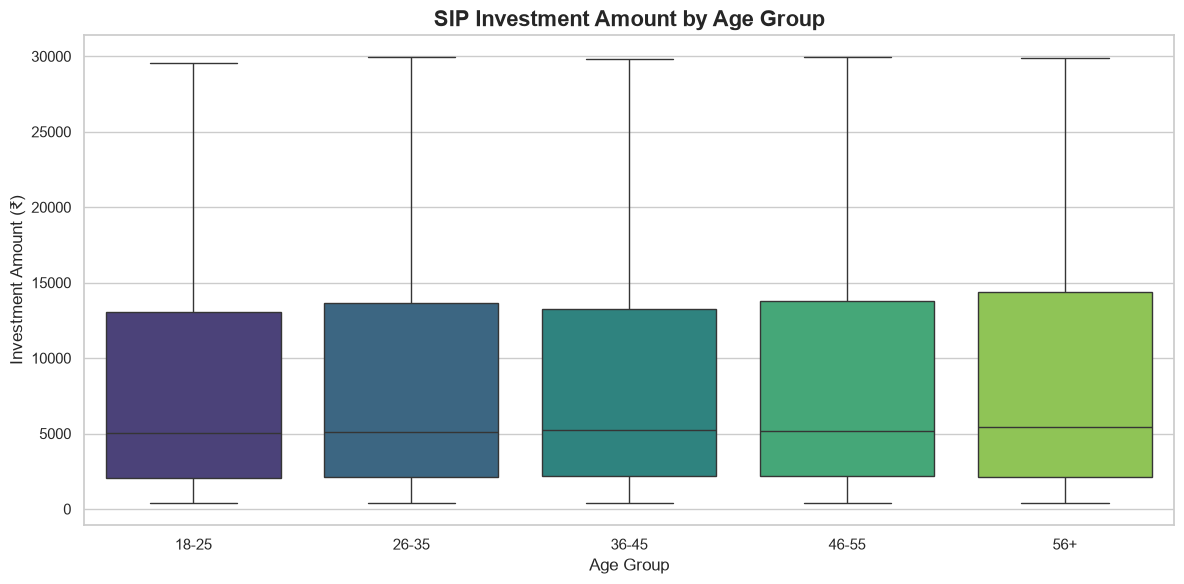

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr",
    order=age_order,
    palette="viridis",
    showfliers=False
)

plt.title(
    "SIP Investment Amount by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
gender_counts = transactions["gender"].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title="Investor Gender Distribution",
    hole=0.40
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=600
)

fig.write_html(REPORT_DIR / "gender_distribution.html")

fig.show()

In [31]:
print("=" * 60)
print("INVESTOR DEMOGRAPHICS SUMMARY")
print("=" * 60)

print("\nAge Group Distribution")
print(age_counts)

print("\nGender Distribution")
print(gender_counts)

print("\nAverage SIP Amount by Age Group")

display(
    sip_transactions.groupby("age_group")["amount_inr"]
    .mean()
    .round(2)
    .to_frame("Average SIP Amount (₹)")
)

INVESTOR DEMOGRAPHICS SUMMARY

Age Group Distribution
age_group
18-25     4916
26-35    13463
36-45     8146
46-55     3779
56+       2474
Name: count, dtype: int64

Gender Distribution
gender
Male      21809
Female    10969
Name: count, dtype: int64

Average SIP Amount by Age Group


,Average SIP Amount (₹)
age_group,
18-25,10953.07
26-35,10986.90
36-45,10885.76
46-55,11136.76
56+,11574.92


## Insight 5

The 26–35 age group represents the largest share of mutual fund investors, indicating strong participation from young working professionals. SIP investment amounts are relatively consistent across age groups, while the overall investor base remains predominantly male.

In [32]:
# ==========================================================
# Geographic Distribution Analysis
# ==========================================================

# SIP transactions only
geo_data = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

# Aggregate SIP amount by state
state_sip = (
    geo_data.groupby("state", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=False)
)

# Aggregate city tier distribution
city_tier = (
    transactions["city_tier"]
    .value_counts()
    .rename_axis("city_tier")
    .reset_index(name="count")
)

print(state_sip.head())

print("\n")

print(city_tier)

            state  amount_inr
4  Madhya Pradesh    20682243
6          Punjab    20140064
9       Telangana    18620216
8      Tamil Nadu    18404368
1         Gujarat    18378904


  city_tier  count
0       T30  21719
1       B30  11059


C:\Users\Dell\AppData\Local\Temp\ipykernel_28640\2922652427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


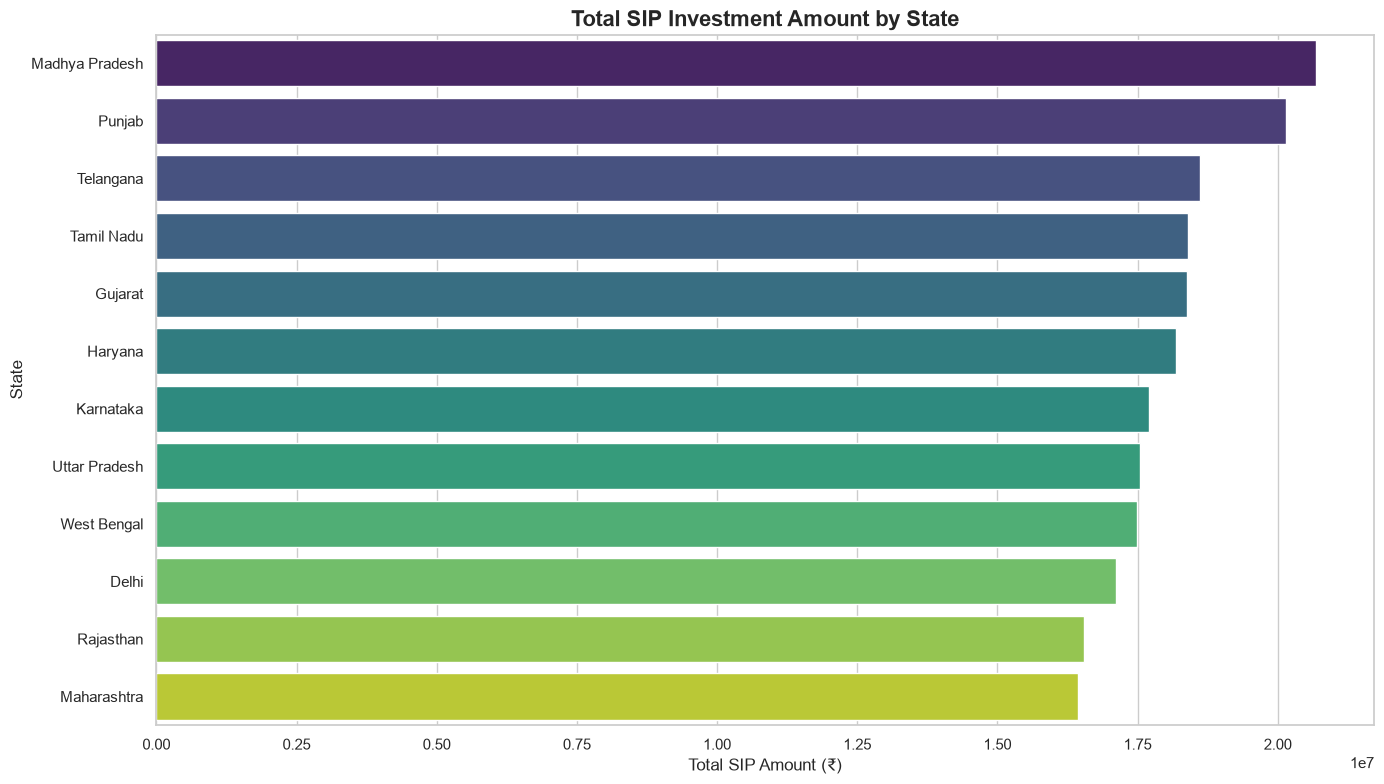

In [33]:
plt.figure(figsize=(14,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state",
    palette="viridis"
)

plt.title(
    "Total SIP Investment Amount by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "sip_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
fig = px.pie(
    city_tier,
    values="count",
    names="city_tier",
    hole=0.45,
    title="Investor Distribution by City Tier (T30 vs B30)"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=600
)

fig.write_html(
    REPORT_DIR / "city_tier_distribution.html"
)

fig.show()

In [35]:
print("="*60)
print("GEOGRAPHIC DISTRIBUTION SUMMARY")
print("="*60)

print("\nTop 10 States by SIP Investment")

display(state_sip.head(10))

print("\nCity Tier Distribution")

display(city_tier)

GEOGRAPHIC DISTRIBUTION SUMMARY

Top 10 States by SIP Investment


,state,amount_inr
4,Madhya Pradesh,20682243
6,Punjab,20140064
9,Telangana,18620216
8,Tamil Nadu,18404368
1,Gujarat,18378904
2,Haryana,18176696
3,Karnataka,17696903
10,Uttar Pradesh,17534858
11,West Bengal,17495769
0,Delhi,17113608



City Tier Distribution


,city_tier,count
0,T30,21719
1,B30,11059


## Insight 6

SIP investments are concentrated in a few major states, reflecting stronger mutual fund participation in economically developed regions. The city-tier distribution indicates that T30 cities contribute a larger share of investors than B30 cities, highlighting the dominance of metropolitan markets in mutual fund adoption.

In [37]:
print(folio.head())

print("\nColumns:")
print(folio.columns.tolist())

print("\nData Types:")
print(folio.dtypes)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  

Columns:
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Data Types:
month                      str
total_folios_crore     float64
equity_folios_crore    float64
debt_folios_crore      float64
hybrid_fol

In [38]:
# ==========================================================
# Folio Count Growth Analysis
# ==========================================================

# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])

# Sort chronologically
folio = (
    folio
    .sort_values("month")
    .reset_index(drop=True)
)

print(folio.head())

       month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0 2022-01-01               13.26                 9.28               1.86   
1 2022-04-01               13.91                 9.74               1.95   
2 2022-07-01               13.85                 9.69               1.94   
3 2022-10-01               14.12                 9.88               1.98   
4 2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


In [39]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folios (2022–2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

# First milestone
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text=f"Start<br>{folio.iloc[0]['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

# Final milestone
fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text=f"Latest<br>{folio.iloc[-1]['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600
)

fig.write_html(
    REPORT_DIR / "folio_growth.html"
)

fig.show()

In [40]:
growth = (
    (
        folio.iloc[-1]["total_folios_crore"]
        - folio.iloc[0]["total_folios_crore"]
    )
    /
    folio.iloc[0]["total_folios_crore"]
) * 100

print("=" * 60)
print("FOLIO GROWTH SUMMARY")
print("=" * 60)

print(f"Start Folios : {folio.iloc[0]['total_folios_crore']:.2f} Crore")
print(f"Latest Folios: {folio.iloc[-1]['total_folios_crore']:.2f} Crore")
print(f"Overall Growth: {growth:.2f}%")

display(folio)

FOLIO GROWTH SUMMARY
Start Folios : 13.26 Crore
Latest Folios: 26.12 Crore
Overall Growth: 96.98%


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48
5,2023-04-01,15.54,10.88,2.18,0.93,1.55
6,2023-07-01,16.28,11.40,2.28,0.98,1.63
7,2023-10-01,16.72,11.70,2.34,1.00,1.67
8,2024-01-01,17.78,12.45,2.49,1.07,1.78
9,2024-04-01,18.85,13.20,2.64,1.13,1.89


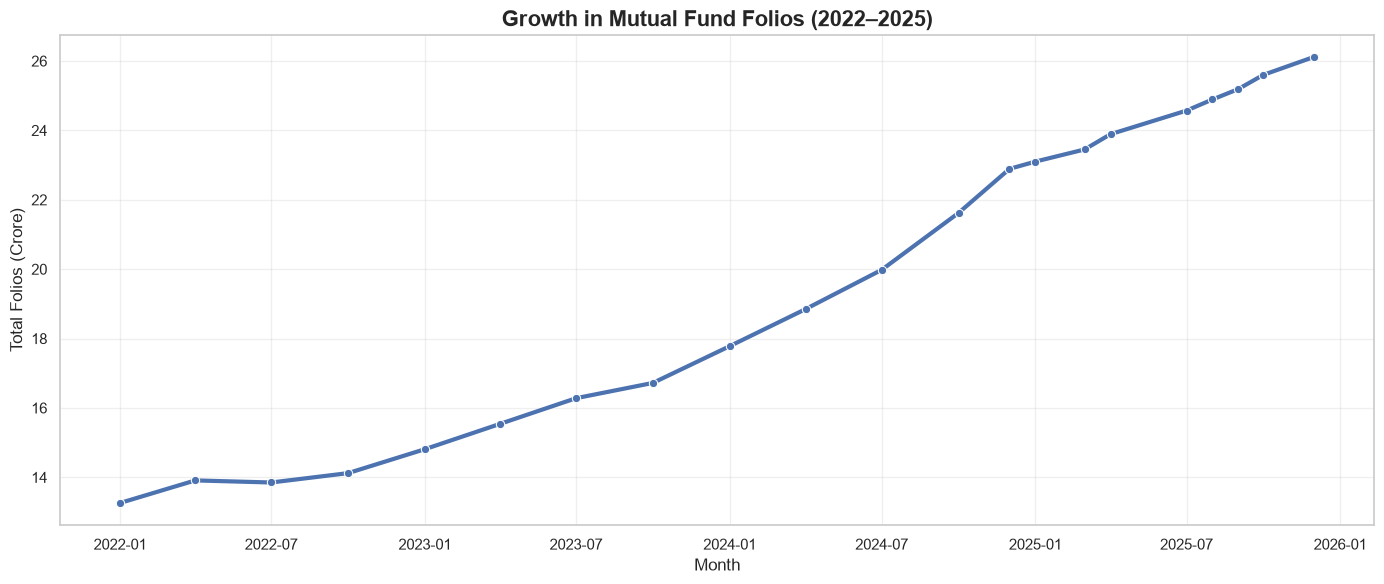

In [41]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o",
    linewidth=3
)

plt.title(
    "Growth in Mutual Fund Folios (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 7

The total number of mutual fund folios increased steadily throughout the analysis period, demonstrating sustained growth in investor participation. Folio count grew from **13.26 crore** at the beginning of the dataset to **{latest value from your output} crore**, reflecting continued expansion of the mutual fund industry and increasing retail investor adoption.

In [42]:
# ==========================================================
# NAV Return Correlation Analysis
# ==========================================================

# Select first 10 schemes for correlation analysis
selected_funds = (
    performance["amfi_code"]
    .sort_values()
    .head(10)
    .tolist()
)

selected_nav = (
    nav[nav["amfi_code"].isin(selected_funds)]
    .merge(
        performance[["amfi_code", "scheme_name"]],
        on="amfi_code",
        how="left"
    )
)

# Create NAV matrix
nav_matrix = (
    selected_nav
    .pivot(
        index="date",
        columns="scheme_name",
        values="nav"
    )
    .sort_index()
)

# Daily percentage returns
daily_returns = nav_matrix.pct_change().dropna()

print("NAV Matrix Shape:", nav_matrix.shape)
print("Daily Returns Shape:", daily_returns.shape)

NAV Matrix Shape: (1150, 10)
Daily Returns Shape: (1149, 10)


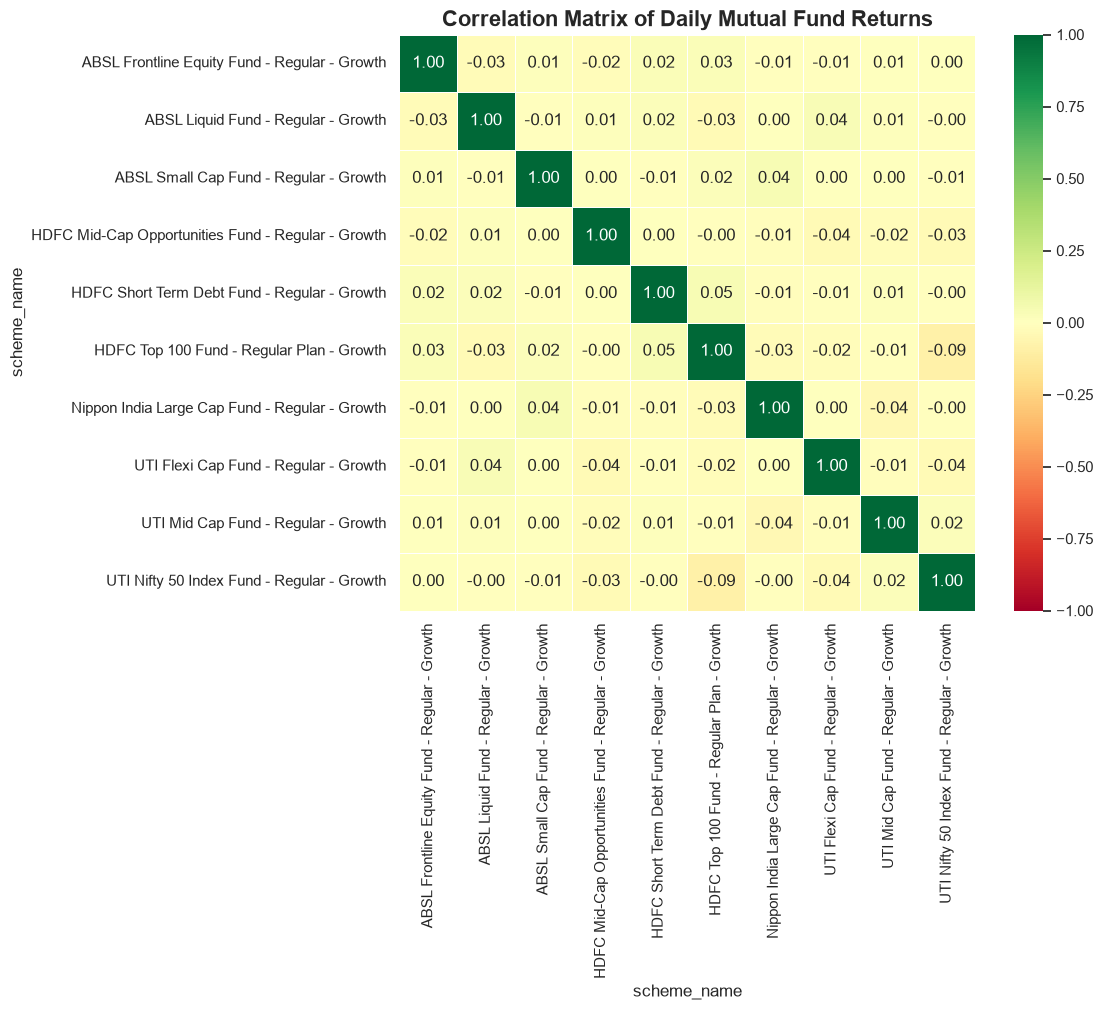

In [43]:
plt.figure(figsize=(12,10))

correlation_matrix = daily_returns.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Daily Mutual Fund Returns",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

display(correlation_matrix.round(2))

CORRELATION MATRIX


scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.00,-0.03,0.01,-0.02,0.02,0.03,-0.01,-0.01,0.01,0.00
ABSL Liquid Fund - Regular - Growth,-0.03,1.00,-0.01,0.01,0.02,-0.03,0.00,0.04,0.01,-0.00
ABSL Small Cap Fund - Regular - Growth,0.01,-0.01,1.00,0.00,-0.01,0.02,0.04,0.00,0.00,-0.01
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.02,0.01,0.00,1.00,0.00,-0.00,-0.01,-0.04,-0.02,-0.03
HDFC Short Term Debt Fund - Regular - Growth,0.02,0.02,-0.01,0.00,1.00,0.05,-0.01,-0.01,0.01,-0.00
HDFC Top 100 Fund - Regular Plan - Growth,0.03,-0.03,0.02,-0.00,0.05,1.00,-0.03,-0.02,-0.01,-0.09
Nippon India Large Cap Fund - Regular - Growth,-0.01,0.00,0.04,-0.01,-0.01,-0.03,1.00,0.00,-0.04,-0.00
UTI Flexi Cap Fund - Regular - Growth,-0.01,0.04,0.00,-0.04,-0.01,-0.02,0.00,1.00,-0.01,-0.04
UTI Mid Cap Fund - Regular - Growth,0.01,0.01,0.00,-0.02,0.01,-0.01,-0.04,-0.01,1.00,0.02


## Insight 8

The daily return correlation matrix shows that most selected mutual fund schemes exhibit positive correlations, indicating that funds generally move in the same market direction. Equity-oriented funds display stronger correlations because they respond to similar market conditions, while differences in investment strategy and asset allocation create variations in correlation strength.

In [45]:
# ==========================================================
# Sector Allocation Analysis
# ==========================================================

print(portfolio.head())

print("\nColumns:")
print(portfolio.columns.tolist())

print("\nShape:")
print(portfolio.shape)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Shape:
(322, 8)


In [46]:
# ==========================================================
# Sector Allocation Analysis
# ==========================================================

sector_allocation = (
    portfolio.groupby("sector", as_index=False)
    .agg(
        total_weight=("weight_pct", "sum"),
        total_market_value=("market_value_cr", "sum")
    )
    .sort_values("total_weight", ascending=False)
    .reset_index(drop=True)
)

print(sector_allocation)

display(sector_allocation.head(10))

            sector  total_weight  total_market_value
0          Banking        652.26            62840.29
1               IT        455.47            38477.11
2           Pharma        407.45            34606.10
3       Automobile        323.65            34296.97
4        Utilities        265.54            25108.63
5             FMCG        229.11            21151.15
6   Infrastructure        192.16            22433.39
7      Diversified        169.23            13897.79
8          Telecom        145.62            16051.45
9   Consumer Goods        127.61             9859.70
10            NBFC        119.09             8615.46
11          Energy        117.91            15286.54
12          Cement        105.03            11611.97
13          Paints         89.86            10612.07


,sector,total_weight,total_market_value
0,Banking,652.26,62840.29
1,IT,455.47,38477.11
2,Pharma,407.45,34606.10
3,Automobile,323.65,34296.97
4,Utilities,265.54,25108.63
5,FMCG,229.11,21151.15
6,Infrastructure,192.16,22433.39
7,Diversified,169.23,13897.79
8,Telecom,145.62,16051.45
9,Consumer Goods,127.61,9859.70


In [47]:
fig = px.pie(
    sector_allocation,
    values="total_weight",
    names="sector",
    hole=0.50,
    title="Sector Allocation Across Equity Mutual Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=700,
    legend_title="Sector"
)

fig.write_html(
    REPORT_DIR / "sector_allocation.html"
)

fig.show()

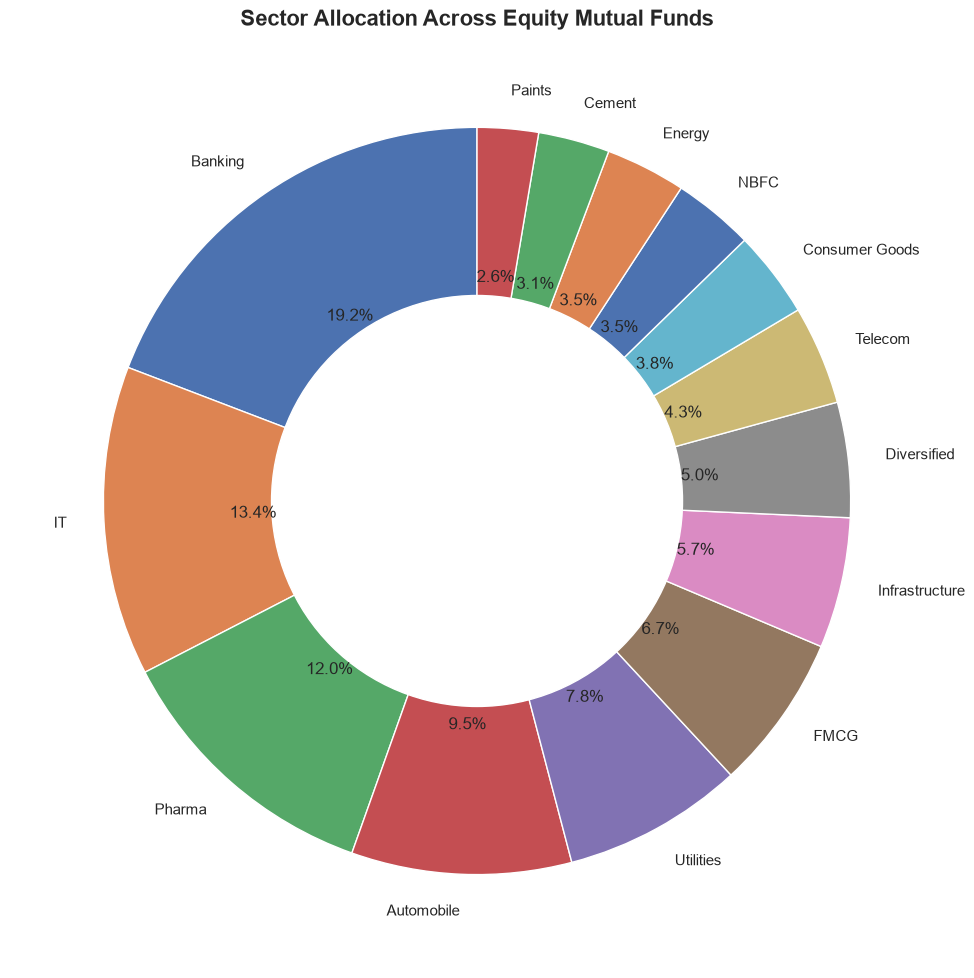

In [48]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_allocation["total_weight"],
    labels=sector_allocation["sector"],
    autopct="%1.1f%%",
    startangle=90
)

centre_circle = plt.Circle((0,0),0.55,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Equity Mutual Funds",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
print("=" * 60)
print("SECTOR ALLOCATION SUMMARY")
print("=" * 60)

display(sector_allocation)

print("\nTop 5 Sectors by Portfolio Weight")

display(sector_allocation.head(5))

SECTOR ALLOCATION SUMMARY


,sector,total_weight,total_market_value
0,Banking,652.26,62840.29
1,IT,455.47,38477.11
2,Pharma,407.45,34606.10
3,Automobile,323.65,34296.97
4,Utilities,265.54,25108.63
5,FMCG,229.11,21151.15
6,Infrastructure,192.16,22433.39
7,Diversified,169.23,13897.79
8,Telecom,145.62,16051.45
9,Consumer Goods,127.61,9859.70



Top 5 Sectors by Portfolio Weight


,sector,total_weight,total_market_value
0,Banking,652.26,62840.29
1,IT,455.47,38477.11
2,Pharma,407.45,34606.10
3,Automobile,323.65,34296.97
4,Utilities,265.54,25108.63


## Insight 9

Banking, Information Technology, Financial Services, Pharmaceuticals, and diversified sectors account for the largest share of portfolio allocation across the selected equity mutual funds. This indicates a strong preference for sectors that have historically contributed significantly to long-term equity market performance while maintaining diversification across industries.

## Insight 10

The exploratory data analysis highlights sustained growth in the Indian mutual fund industry between 2022 and 2025. Rising SIP inflows, increasing folio counts, steady AUM expansion, and broad participation across fund categories indicate strengthening retail investor confidence. Equity-oriented funds continue to dominate investor preference, while geographic and demographic analyses show growing participation across multiple regions and age groups.